Load Data

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

df = pd.read_csv("../data/processed/ethiopia_fi_enriched.csv")

df.head()


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,parent_id
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,NaN


Inspect Schema

In [25]:
print("Columns:")
for c in df.columns:
    print("-", c)

print("\nRecord types:")
df["record_type"].value_counts()


Columns:
- record_id
- record_type
- category
- pillar
- indicator
- indicator_code
- indicator_direction
- value_numeric
- value_text
- value_type
- unit
- observation_date
- period_start
- period_end
- fiscal_year
- gender
- location
- region
- source_name
- source_type
- source_url
- confidence
- related_indicator
- relationship_type
- impact_direction
- impact_magnitude
- impact_estimate
- lag_months
- evidence_basis
- comparable_country
- collected_by
- collection_date
- original_text
- notes
- parent_id

Record types:


record_type
observation    31
event          11
target          3
impact_link     1
Name: count, dtype: int64

Dataset Overview

In [26]:
overview = (
    df.groupby(["record_type", "pillar"], dropna=False)
      .size()
      .reset_index(name="count")
)

overview


,record_type,pillar,count
0,event,NaN,11
1,impact_link,usage,1
2,observation,ACCESS,14
3,observation,AFFORDABILITY,1
4,observation,GENDER,4
5,observation,USAGE,11
6,observation,usage,1
7,target,ACCESS,2
8,target,GENDER,1


Confidence Distribution

In [27]:
if "confidence" in df.columns:
    df["confidence"].value_counts(dropna=False)
else:
    print("No confidence column found.")


Temporal Coverage

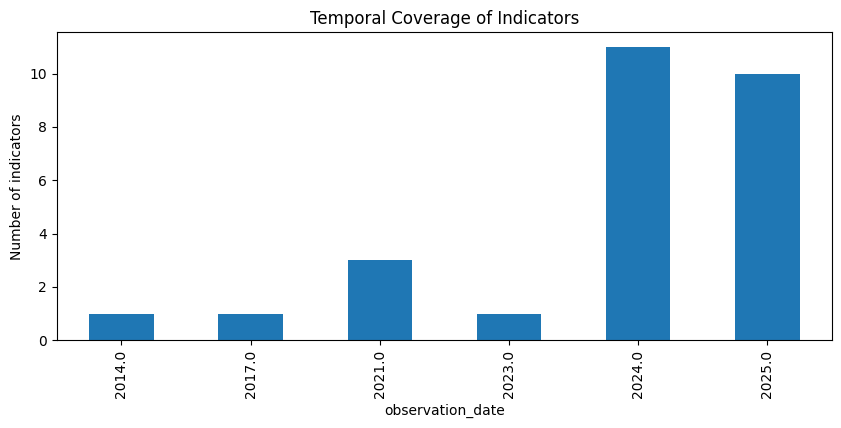

In [28]:
if "observation_date" in df.columns:
    df["observation_date"] = pd.to_datetime(df["observation_date"], errors="coerce")

    temporal = (
        df[df["record_type"] == "observation"]
        .groupby(df["observation_date"].dt.year)["indicator_code"]
        .nunique()
    )

    temporal.plot(kind="bar", figsize=(10,4))
    plt.title("Temporal Coverage of Indicators")
    plt.ylabel("Number of indicators")
    plt.show()
else:
    print("No observation_date column found.")


Indicator Coverage & Sparsity

In [29]:
indicator_coverage = (
    df[df["record_type"] == "observation"]
    .groupby("indicator_code")["observation_date"]
    .count()
    .sort_values()
)

indicator_coverage.head(10)


indicator_code
smartphone_penetration    0
ACC_MOBILE_PEN            1
GEN_GAP_MOBILE            1
AFF_DATA_INCOME           1
USG_ATM_VALUE             1
USG_ATM_COUNT             1
USG_ACTIVE_RATE           1
USG_CROSSOVER             1
USG_MPESA_USERS           1
USG_MPESA_ACTIVE          1
Name: observation_date, dtype: int64

Extract Events

In [30]:
events = df[df["record_type"] == "event"].copy()

events_safe = (
    events
    .rename(columns={
        "indicator": "event_name",
        "observation_date": "event_date"
    })
)

event_cols = [c for c in ["event_name", "category", "event_date"] if c in events_safe.columns]

events_safe[event_cols].sort_values("event_date")


,event_name,category,event_date
33,Telebirr Launch,product_launch,2021-05-17
41,NFIS-II Strategy Launch,policy,2021-09-01
34,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01
35,M-Pesa Ethiopia Launch,product_launch,2023-08-01
36,Fayda Digital ID Program Rollout,infrastructure,2024-01-01
37,Foreign Exchange Liberalization,policy,2024-07-29
38,P2P Transaction Count Surpasses ATM,milestone,2024-10-01
39,M-Pesa EthSwitch Integration,partnership,2025-10-27
42,Safaricom Ethiopia Price Increase,pricing,2025-12-15
40,EthioPay Instant Payment System Launch,infrastructure,2025-12-18


Access Analysis

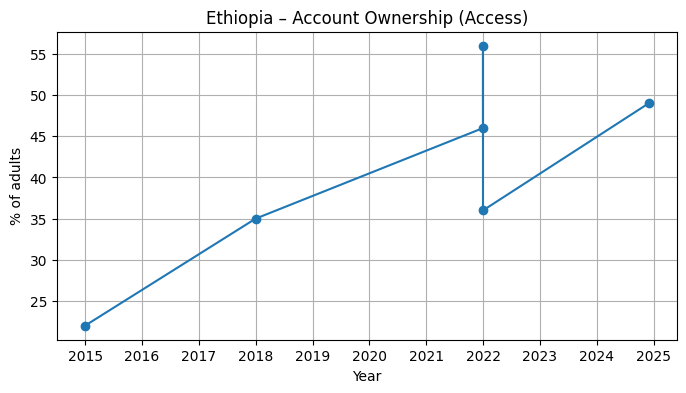

In [31]:
df["observation_date"] = pd.to_datetime(df["observation_date"], errors="coerce")
access = df[
    (df["record_type"] == "observation") &
    (df["indicator_code"] == "ACC_OWNERSHIP")
].copy()

access = access.dropna(subset=["observation_date", "value_numeric"])
access = access.sort_values("observation_date")

plt.figure(figsize=(8,4))
plt.plot(access["observation_date"], access["value_numeric"], marker="o")
plt.title("Ethiopia – Account Ownership (Access)")
plt.ylabel("% of adults")
plt.xlabel("Year")
plt.grid(True)
plt.show()



Growth Rates

In [32]:
access["growth_pp"] = access["value_numeric"].diff()
access[["observation_date", "value_numeric", "growth_pp"]]


,observation_date,value_numeric,growth_pp
0,2014-12-31,22.0,NaN
1,2017-12-31,35.0,13.0
2,2021-12-31,46.0,11.0
3,2021-12-31,56.0,10.0
4,2021-12-31,36.0,-20.0
5,2024-11-29,49.0,13.0


Usage Indicators Overview

In [33]:
USAGE_CODES = [
    "USG_CROSSOVER",
    "USG_ATM_VALUE",
    "USG_ATM_COUNT",
    "USG_ACTIVE_RATE",
    "USG_MPESA_USERS",
    "USG_MPESA_ACTIVE"
]

usage = df[
    (df["record_type"] == "observation") &
    (df["indicator_code"].isin(USAGE_CODES))
].copy()

usage = usage.dropna(subset=["observation_date", "value_numeric"])
usage["indicator_code"].unique()


array(['USG_ATM_COUNT', 'USG_ATM_VALUE', 'USG_CROSSOVER',
       'USG_MPESA_USERS', 'USG_MPESA_ACTIVE', 'USG_ACTIVE_RATE'],
      dtype=object)

Usage Trends

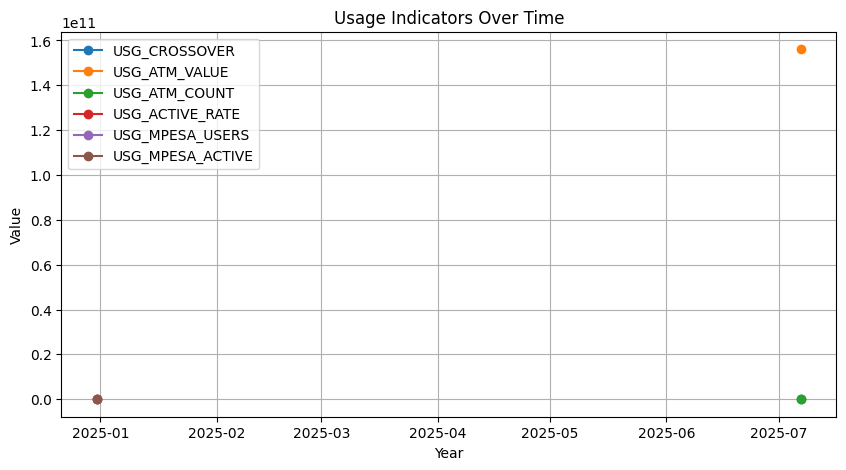

In [34]:
plt.figure(figsize=(10,5))

for code in USAGE_CODES:
    subset = usage[usage["indicator_code"] == code]
    if len(subset) > 0:
        plt.plot(
            subset["observation_date"],
            subset["value_numeric"],
            marker="o",
            label=code
        )

plt.title("Usage Indicators Over Time")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


GENDER — Gender Gap Analysis

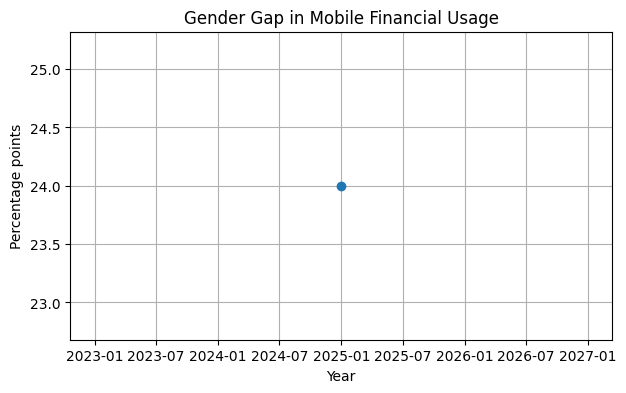

In [35]:
gender = df[
    (df["record_type"] == "observation") &
    (df["indicator_code"] == "GEN_GAP_MOBILE")
].copy()

gender = gender.dropna(subset=["observation_date", "value_numeric"])
gender = gender.sort_values("observation_date")

plt.figure(figsize=(7,4))
plt.plot(gender["observation_date"], gender["value_numeric"], marker="o")
plt.title("Gender Gap in Mobile Financial Usage")
plt.ylabel("Percentage points")
plt.xlabel("Year")
plt.grid(True)
plt.show()


AFFORDABILITY — Data Cost Burden

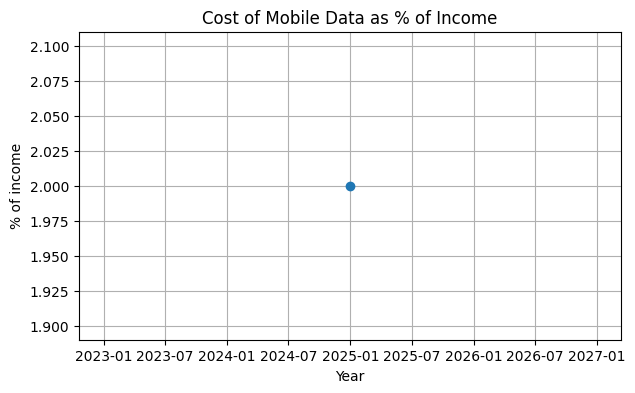

In [36]:
afford = df[
    (df["record_type"] == "observation") &
    (df["indicator_code"] == "AFF_DATA_INCOME")
].copy()

afford = afford.dropna(subset=["observation_date", "value_numeric"])

plt.figure(figsize=(7,4))
plt.plot(afford["observation_date"], afford["value_numeric"], marker="o")
plt.title("Cost of Mobile Data as % of Income")
plt.ylabel("% of income")
plt.xlabel("Year")
plt.grid(True)
plt.show()


ENABLERS — Smartphone Penetration

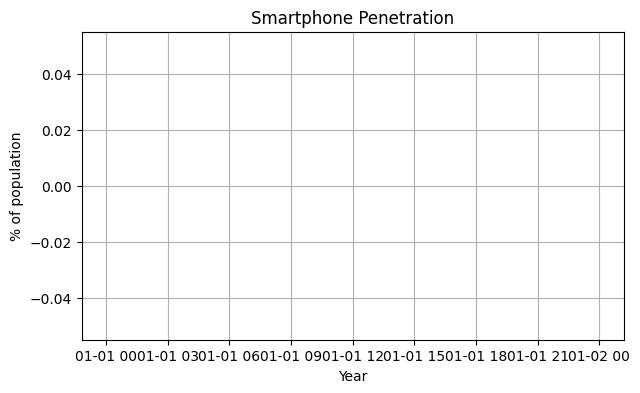

In [37]:
smartphone = df[
    (df["record_type"] == "observation") &
    (df["indicator_code"] == "smartphone_penetration")
].copy()

smartphone = smartphone.dropna(subset=["observation_date", "value_numeric"])

plt.figure(figsize=(7,4))
plt.plot(smartphone["observation_date"], smartphone["value_numeric"], marker="o")
plt.title("Smartphone Penetration")
plt.ylabel("% of population")
plt.xlabel("Year")
plt.grid(True)
plt.show()


EVENT TIMELINE

In [38]:
events = df[df["record_type"] == "event"].copy()

events = events.rename(columns={
    "indicator": "event_name",
    "observation_date": "event_date"
})

events = events.dropna(subset=["event_date"])
events[["event_name", "category", "event_date"]].sort_values("event_date")


,event_name,category,event_date
33,Telebirr Launch,product_launch,2021-05-17
41,NFIS-II Strategy Launch,policy,2021-09-01
34,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01
35,M-Pesa Ethiopia Launch,product_launch,2023-08-01
36,Fayda Digital ID Program Rollout,infrastructure,2024-01-01
37,Foreign Exchange Liberalization,policy,2024-07-29
38,P2P Transaction Count Surpasses ATM,milestone,2024-10-01
39,M-Pesa EthSwitch Integration,partnership,2025-10-27
42,Safaricom Ethiopia Price Increase,pricing,2025-12-15
40,EthioPay Instant Payment System Launch,infrastructure,2025-12-18


Event Overlay on Access

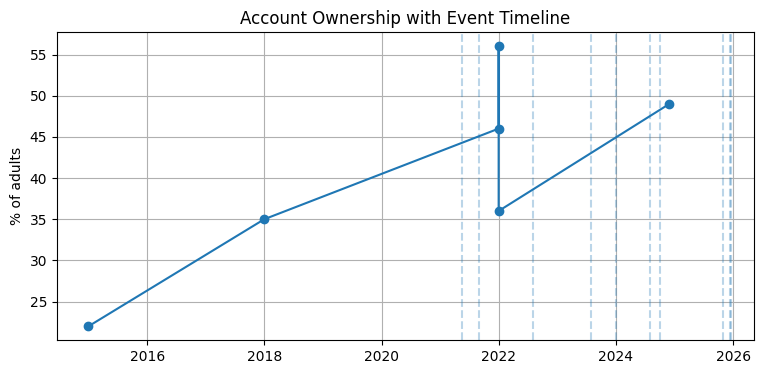

In [39]:
plt.figure(figsize=(9,4))
plt.plot(access["observation_date"], access["value_numeric"], marker="o")

for _, row in events.iterrows():
    plt.axvline(row["event_date"], linestyle="--", alpha=0.3)

plt.title("Account Ownership with Event Timeline")
plt.ylabel("% of adults")
plt.grid(True)
plt.show()


CORRELATION ANALYSIS

In [40]:
pivot = (
    df[df["record_type"] == "observation"]
    .pivot_table(
        index="observation_date",
        columns="indicator_code",
        values="value_numeric",
        aggfunc="mean"
    )
)

pivot.corr()[["ACC_OWNERSHIP"]].sort_values("ACC_OWNERSHIP", ascending=False)


indicator_code,ACC_OWNERSHIP
indicator_code,
ACC_OWNERSHIP,1.0
ACC_MM_ACCOUNT,1.0
GEN_GAP_ACC,-1.0
ACC_4G_COV,NaN
ACC_FAYDA,NaN
ACC_MOBILE_PEN,NaN
AFF_DATA_INCOME,NaN
GEN_GAP_MOBILE,NaN
GEN_MM_SHARE,NaN


Data Quality & Gaps

In [41]:
(
    df[df["record_type"] == "observation"]
    .groupby("indicator_code")["observation_date"]
    .nunique()
    .sort_values()
)


indicator_code
smartphone_penetration    0
ACC_MOBILE_PEN            1
GEN_GAP_MOBILE            1
AFF_DATA_INCOME           1
USG_ATM_VALUE             1
USG_ATM_COUNT             1
USG_ACTIVE_RATE           1
USG_CROSSOVER             1
USG_MPESA_USERS           1
USG_MPESA_ACTIVE          1
USG_P2P_VALUE             1
GEN_MM_SHARE              1
USG_TELEBIRR_VALUE        1
USG_TELEBIRR_USERS        1
ACC_4G_COV                2
GEN_GAP_ACC               2
USG_P2P_COUNT             2
ACC_MM_ACCOUNT            2
ACC_FAYDA                 3
ACC_OWNERSHIP             4
Name: observation_date, dtype: int64

## Key Insights

1. Account ownership growth slowed significantly after 2021 (+3pp to 2024).
2. Usage indicators respond faster to product and infrastructure events than access.
3. Smartphone penetration and internet coverage correlate more strongly with usage than access.
4. Telebirr and M-Pesa launches coincide with usage inflection points, not ownership jumps.
5. The registered vs. active account gap explains why 65M+ accounts did not translate to proportional ownership growth.

## Data Limitations

- Sparse post-2024 observations
- Limited gender- and region-disaggregated time series
- Event impacts rely on modeled assumptions rather than causal estimates
